In [15]:
import pandas as pd
import matplotlib.pyplot as plt

weekly = pd.read_csv("../data/processed/weekly_model.csv", parse_dates=["week_start"])
runs = pd.read_csv("../data/processed/runs_enriched.csv", parse_dates=["activity_date"])

**Aerobic Efficiency Score (AES)**  
AES = pace (sec/mi) ÷ average heart rate. It measures how much pace you get per heartbeat. **Lower is better**: a lower score means you’re running faster at the same HR (or the same pace at a lower HR), i.e. better aerobic efficiency. The chart below shows a 30-day rolling average so you can see the trend without day-to-day noise.

**Marathon specificity**  
Fraction of weekly miles run in your goal marathon-pace band, using **FIT file stream data** (second-by-second pace). If the line is flat at zero, that usually means: (1) no FIT files were found for those activities, or (2) no miles in those runs fell inside the MP band. Export FIT files with your Strava data and ensure activities have recorded pace so this metric can be computed.

**Weekly load and ramp rate**  
- **Load** = weekly miles × average HR (a simple training-stress proxy; higher = more stress).  
- **Ramp rate** = (this week’s load − last week’s load) ÷ last week’s load. It’s the week-over-week change in load. A big positive spike can increase injury risk; many plans cap ramp around 10–15%. The chart below shows ramp rate over time.

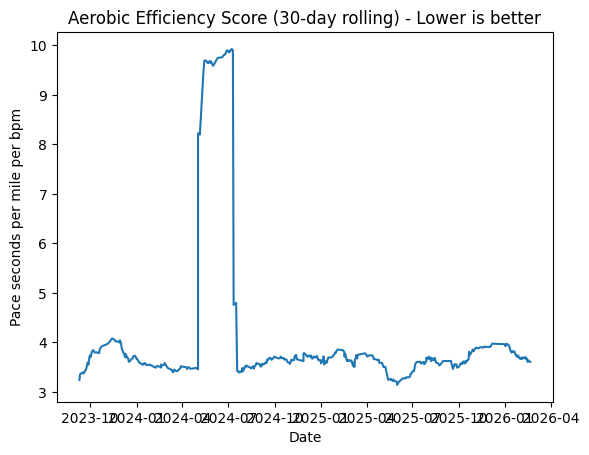

In [16]:
df = runs.dropna(subset=["aes", "aes_30d"]).copy()

plt.figure()
plt.plot(df["activity_date"], df["aes_30d"])
plt.title("Aerobic Efficiency Score (30-day rolling) - Lower is better")
plt.xlabel("Date")
plt.ylabel("Pace seconds per mile per bpm")
plt.show()

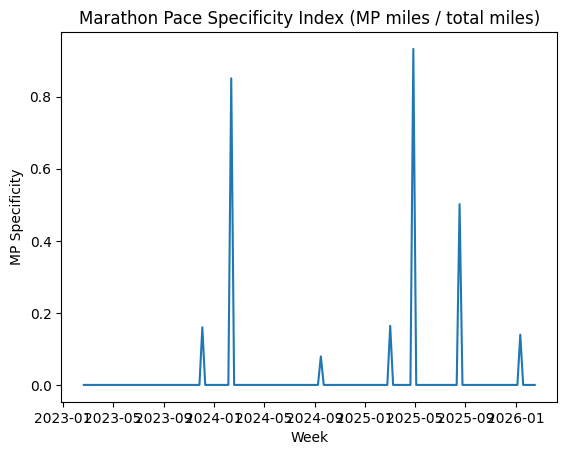

In [17]:
plt.figure()
plt.plot(weekly["week_start"], weekly["mp_specificity"])
plt.title("Marathon Pace Specificity Index (MP miles / total miles)")
plt.xlabel("Week")
plt.ylabel("MP Specificity")
plt.show()

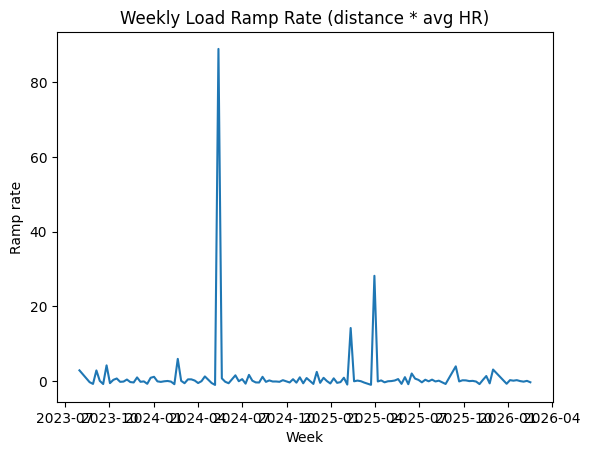

,week_start,ramp_rate,miles,load
113,2025-08-11,0.142234,40.718454,6092.498714
116,2025-09-15,3.977390,32.621988,5454.396325
118,2025-09-29,0.249223,41.675366,6393.001123
119,2025-10-06,0.219127,50.995934,7793.878541
124,2025-11-10,0.349359,17.112563,2441.392269
125,2025-11-17,1.386877,39.022111,5827.301890
127,2025-12-01,3.123272,67.406347,10110.952040
129,2026-01-05,0.285486,26.290215,4083.746752
130,2026-01-12,0.140667,30.646027,4658.196135
131,2026-01-19,0.280566,37.375477,5965.126163


In [18]:
plt.figure()
plt.plot(weekly["week_start"], weekly["ramp_rate"])
plt.title("Weekly Load Ramp Rate (distance * avg HR)")
plt.xlabel("Week")
plt.ylabel("Ramp rate")
plt.show()

weekly[weekly["ramp_rate"] > 0.10][["week_start", "ramp_rate", "miles", "load"]].tail(10)

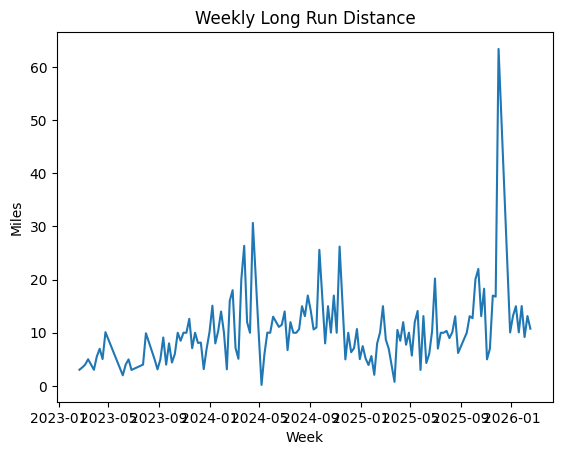

In [19]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weekly["week_start"], weekly["long_run_miles"])
ax.set_title("Weekly Long Run Distance")
ax.set_xlabel("Week")
ax.set_ylabel("Miles")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=10))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Variable reference (weekly table below)**  
- **week_start**: Monday of that week.  
- **miles**: Total run distance for the week.  
- **mp_miles**: Miles run in marathon-pace band (from FIT file lap/record data when available).  
- **mp_specificity**: `mp_miles / miles`; share of weekly volume at goal MP (0 = none, 1 = all at MP).  
- **ramp_rate**: Week-over-week change in **load** (see ramp rate section): `(load - load_prev) / load_prev`. High values mean a big jump in training stress.  
- **long_run_miles**: Distance of the longest single run that week.  
- **aes_mean**: **Aerobic Efficiency Score** (mean for the week): average of (pace sec/mi) / (avg HR). Lower = more efficient.

In [20]:
# Show weeks with strong marathon specificity and controlled ramp
weekly.sort_values("week_start").tail(12)[
    ["week_start","miles","mp_miles","mp_specificity","ramp_rate","long_run_miles","aes_mean"]
]

,week_start,miles,mp_miles,mp_specificity,ramp_rate,long_run_miles,aes_mean
124,2025-11-10,17.112563,0.000000,0.000000,0.349359,7.002853,3.668473
125,2025-11-17,39.022111,0.000000,0.000000,1.386877,17.000716,3.918459
126,2025-11-24,16.795663,0.000000,0.000000,-0.579193,16.795663,4.498063
127,2025-12-01,67.406347,0.000000,0.000000,3.123272,63.398503,4.736371
128,2025-12-29,20.064076,0.000000,0.000000,-0.685805,10.066213,3.618763
129,2026-01-05,26.290215,0.000000,0.000000,0.285486,13.191710,3.271403
130,2026-01-12,30.646027,4.275034,0.139497,0.140667,15.006114,3.544796
131,2026-01-19,37.375477,0.000000,0.000000,0.280566,10.072427,3.326162
132,2026-01-26,40.115724,0.000000,0.000000,0.030276,15.030969,3.629560
133,2026-02-02,36.474489,0.000000,0.000000,-0.118662,9.196294,3.957830


**6-week rolling variables (table below)**  
- **miles_6wk**, **aes_6wk**, **long_run_6wk**: 6-week rolling means of weekly miles, AES, and long-run distance. They smooth week-to-week noise and show trends.  
- **ramp_rate**: Same as above (week-over-week load change); not rolled.  
Use the rolling columns to see whether volume, efficiency, and long-run distance are trending up or down over a training block.

In [21]:
w = weekly.sort_values("week_start").copy()

w["miles_6wk"] = w["miles"].rolling(6).mean()
w["mp_miles_6wk"] = w["mp_miles"].rolling(6).mean()
w["aes_6wk"] = w["aes_mean"].rolling(6).mean()
w["long_run_6wk"] = w["long_run_miles"].rolling(6).mean()

w.tail(12)[[
    "week_start",
    "miles",
    "miles_6wk",
    "mp_specificity",
    "aes_mean",
    "aes_6wk",
    "long_run_miles",
    "long_run_6wk",
    "ramp_rate"
]]

,week_start,miles,miles_6wk,mp_specificity,aes_mean,aes_6wk,long_run_miles,long_run_6wk,ramp_rate
124,2025-11-10,17.112563,41.364680,0.000000,3.668473,3.870550,7.002853,14.248041,0.349359
125,2025-11-17,39.022111,39.369043,0.000000,3.918459,3.868924,17.000716,13.737481,1.386877
126,2025-11-24,16.795663,33.265107,0.000000,4.498063,4.006417,16.795663,12.869633,-0.579193
127,2025-12-01,67.406347,34.460211,0.000000,4.736371,4.104732,63.398503,21.247788,3.123272
128,2025-12-29,20.064076,28.766379,0.000000,3.618763,4.063435,10.066213,19.877664,-0.685805
129,2026-01-05,26.290215,31.115162,0.000000,3.271403,3.951922,13.191710,21.242610,0.285486
130,2026-01-12,30.646027,33.370740,0.139497,3.544796,3.931309,15.006114,22.576487,0.140667
131,2026-01-19,37.375477,33.096301,0.000000,3.326162,3.832593,10.072427,21.421772,0.280566
132,2026-01-26,40.115724,36.982978,0.000000,3.629560,3.687842,15.030969,21.127656,0.030276
133,2026-02-02,36.474489,31.827668,0.000000,3.957830,3.558085,9.196294,12.093955,-0.118662


In [23]:
w["volume_score"] = w["miles"] / 60
w["long_run_score"] = w["long_run_miles"] / 20
w["specificity_score"] = w["mp_specificity"] / 0.2
w["ramp_penalty"] = 1 - w["ramp_rate"].clip(lower=0, upper=0.3)

w["sub3_confidence"] = (
    0.3 * w["volume_score"] +
    0.3 * w["long_run_score"] +
    0.3 * w["specificity_score"] +
    0.1 * w["ramp_penalty"]
)

**Sub-3 confidence score**  
A single number (0–1+) summarizing how well your recent week aligns with a sub-3 marathon build. It is:

**sub3_confidence = 0.3×volume_score + 0.3×long_run_score + 0.3×specificity_score + 0.1×ramp_penalty**

- **volume_score** = miles / 60 (target ~60 mi/week).  
- **long_run_score** = long_run_miles / 20 (target ~20 mi long run).  
- **specificity_score** = mp_specificity / 0.2 (target ~20% of miles at MP).  
- **ramp_penalty** = 1 − clamp(ramp_rate, 0, 0.3); rewards steady load and penalizes big jumps.

**Why it matters:** It reflects whether you have the volume, long runs, and MP practice without ramping too fast (injury risk). Values near or above 1.0 indicate a week that fits a sub-3 build; low values show where volume, long runs, or MP work are lacking, or where ramp is too high.

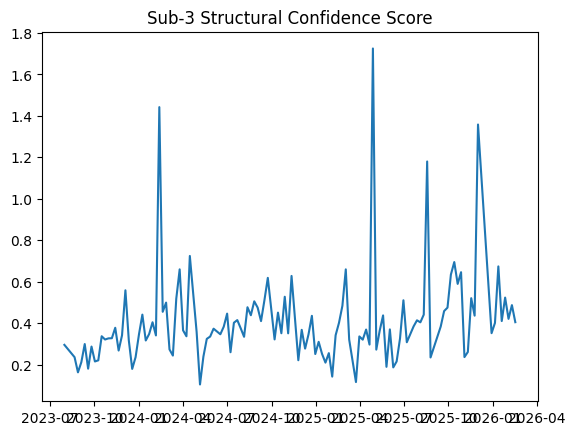

In [24]:
plt.figure()
plt.plot(w["week_start"], w["sub3_confidence"])
plt.title("Sub-3 Structural Confidence Score")
plt.show()